In [2]:
import pandas as pd
import numpy as np 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_excel("Rework_cummulative_brand_data.xlsx")

In [4]:
df.columns = df.columns.str.strip()
df.columns

Index(['Brand', 'Quantity ( Grams)', 'MRP', 'Price', 'Price/100 Grams',
       'Discount (%)'],
      dtype='object')

In [5]:
features = ['Quantity ( Grams)','Price']
df_clean = df.dropna(subset=features).copy()
df_clean
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              448 non-null    object 
 1   Quantity ( Grams)  448 non-null    float64
 2   MRP                448 non-null    int64  
 3   Price              448 non-null    int64  
 4   Price/100 Grams    448 non-null    float64
 5   Discount (%)       448 non-null    int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 21.1+ KB


In [6]:
X = df_clean[features]
X

,Quantity ( Grams),Price
0,70.0,79
1,33.0,29
2,20.0,27
3,200.0,339
4,70.0,79
...,...,...
443,250.0,301
444,100.0,109
445,100.0,109
446,30.0,30


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-5.73053746e-01, -3.62152440e-01],
       [-7.09187529e-01, -4.21743239e-01],
       [-7.57018318e-01, -4.24126871e-01],
       [-9.47458606e-02, -5.22802850e-02],
       [-5.73053746e-01, -3.62152440e-01],
       [-7.09187529e-01, -4.21743239e-01],
       [-5.47298706e-01, -2.79917138e-01],
       [-2.63993266e-01, -1.05912004e-01],
       [-7.57018318e-01, -3.97906920e-01],
       [-6.83432489e-01, -3.51426096e-01],
       [-6.09846661e-01, -2.87068033e-01],
       [-7.57018318e-01, -3.97906920e-01],
       [-6.83432489e-01, -3.58576992e-01],
       [-6.09846661e-01, -3.10904353e-01],
       [ 6.59508882e-01, -4.03621252e-02],
       [-7.57018318e-01, -4.15784159e-01],
       [-6.83432489e-01, -3.76454232e-01],
       [ 1.00904157e+00, -2.78725322e-01],
       [ 2.84868728e+00, -1.07103820e-01],
       [-7.09187529e-01, -4.21743239e-01],
       [-5.47298706e-01, -2.19134522e-01],
       [-2.63993266e-01,  9.69414607e-03],
       [-7.57018318e-01, -3.97906920e-01],
       [-6.

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

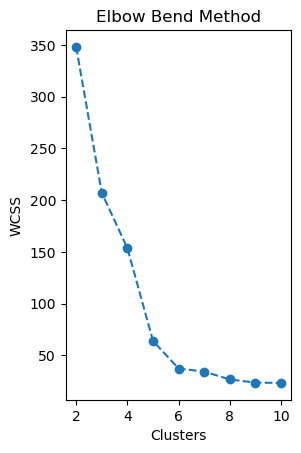

In [8]:
wcss = []
k_range = range(2,11)  # Initialize BEFORE the loop

for k in k_range:
    K_means = KMeans(n_clusters=k)
    K_means.fit(X_scaled)
    wcss.append(K_means.inertia_)

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker="o", linestyle="--")
plt.title("Elbow Bend Method")  # also fix the typo: plt.tite → plt.title
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

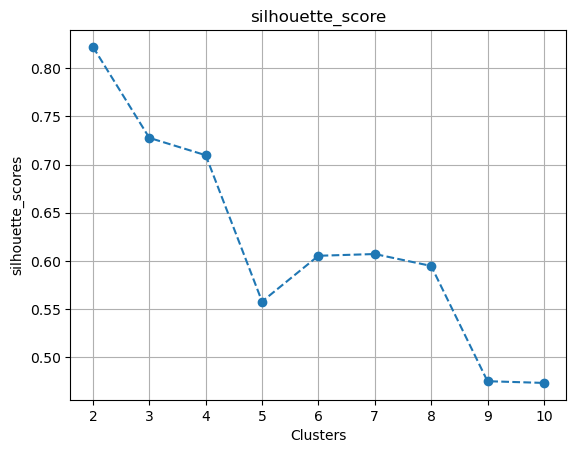

In [9]:
sil_scores = [] 
k_range = range(2,11)
for K in k_range :
    k_means = KMeans(n_clusters=K,random_state=42)
    labels = k_means.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled,labels))
plt.plot(k_range,sil_scores,marker="o",linestyle="--")
plt.title("silhouette_score")
plt.xlabel("Clusters")
plt.ylabel("silhouette_scores")
plt.grid(True)
plt.show()

In [12]:
final_cluster = KMeans(n_clusters=4,random_state=42)
clusters = final_cluster.fit_predict(X)
df["Cluster"] = clusters


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [14]:
df
df.to_excel("Rework_cummulative_brand_data_cluster.xlsx")